## **Создание датасета**
### 1. Скачивание и импорт библиотек

In [4]:
%pip install chembl_webresource_client rdkit pandas tqdm transformers torch

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
# Импорт библиотек
from tqdm import tqdm
from chembl_webresource_client.new_client import new_client
from rdkit import Chem
from sklearn.preprocessing import StandardScaler
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator
from concurrent.futures import ThreadPoolExecutor, as_completed
from transformers import AutoModel, AutoTokenizer
import pandas as pd
import numpy as np
import joblib
import warnings
warnings.filterwarnings('ignore')

print("Библиотеки импортированы успешно!")

d:\projects\bioml\.venv\Lib\site-packages\chembl_webresource_client\__init__.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __version__ = __import__('pkg_resources').get_distribution('chembl_webresource_client').version
d:\projects\bioml\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Библиотеки импортированы успешно!


### 2. Генерация списка биомишеней

In [ ]:
category_keywords = {
    "analgesics": ["COX", "prostaglandin", "opioid", "TRPV", "inflammation", "cytokine"],
    "anti_inflammatories": ["COX", "prostaglandin", "inflammation", "cytokine", "IL", "TNF"],
    "antibiotics": ["gyrase", "penicillin", "dihydrofolate", "polymerase", "beta-lactam", "ribosome"],
    "antihistamines": ["histamine", "H1", "H2", "H3", "H4"],
    "antihypertensives": ["ACE", "angiotensin", "calcium channel", "adrenergic", "renin"],
    "antidiabetics": ["SGLT2", "GLP-1", "PPAR", "insulin", "GLUT", "dipeptidyl"],
    "antidepressants": ["serotonin", "norepinephrine", "MAO", "dopamine", "reuptake"],
    "antivirals": ["HIV", "neuraminidase", "protease", "polymerase", "integrase", "reverse transcriptase"],
    "anticoagulants": ["thrombin", "Factor Xa", "vitamin K", "fibrinogen", "anti-thrombin"]
}

In [6]:
def get_target_ids():
    """
    Получает список биомишеней из ChEMBL, соответствующих указанным категориям лекарств
    и видам (Homo sapiens, Mus musculus, Rattus norvegicus)
    """
    target = new_client.target
    
    all_keywords = []
    for keywords in category_keywords.values():
        all_keywords.extend(keywords)
    
    unique_keywords = list(set(all_keywords))
    regex_pattern = "|".join(unique_keywords)
    
    print(f"Используем ключевые слова для фильтрации: {unique_keywords[:10]}...")
    
    targets = target.filter(
        target_type="SINGLE PROTEIN",
        organism__in=["Homo sapiens", "Mus musculus", "Rattus norvegicus"],
        pref_name__iregex=regex_pattern
    ).only(["target_chembl_id", "pref_name", "organism"])
    
    target_ids = [t["target_chembl_id"] for t in targets]
    
    print(f"Найдено {len(target_ids)} биомишеней для указанных категорий:")
    print(f"Примеры: {target_ids[:10]}")
    
    if len(target_ids) < 300:
        print("\033[93mПредупреждение: Найдено меньше 300 мишеней. Рассмотрите возможность расширения ключевых слов.\033[0m")
    else:
        print("\033[92mДостаточное количество мишеней найдено для обучения.\033[0m")
    
    return target_ids

In [7]:
# Получаем список биомишеней
target_ids = get_target_ids()

# Сохраняем список для последующего использования
print("\nСохраняем список биомишеней в переменную 'target_ids'")

Используем ключевые слова для фильтрации: ['histamine', 'reverse transcriptase', 'dipeptidyl', 'renin', 'ACE', 'prostaglandin', 'PPAR', 'cytokine', 'SGLT2', 'H3']...
Найдено 1316 биомишеней для указанных категорий:
Примеры: ['CHEMBL1971', 'CHEMBL1859', 'CHEMBL402', 'CHEMBL1981', 'CHEMBL209', 'CHEMBL210', 'CHEMBL211', 'CHEMBL213', 'CHEMBL1867', 'CHEMBL1828']
Достаточное количество мишеней найдено для обучения.

Сохраняем список биомишеней в переменную 'target_ids'


### 3. Генерация датасета на основе полученных биомишеней

In [ ]:
def create_dataset(target_ids, pchembl_threshold=6, batch_size=50, max_workers=8):
    """
    Создает датасет с многопоточной обработкой и прогресс-баром
    
    Параметры:
    target_ids (list): Список ChEMBL ID биомишеней
    pchembl_threshold (float): Порог активности (pChEMBL >= threshold)
    batch_size (int): Размер пакета для запросов (рекомендуется 50)
    max_workers (int): Количество потоков (рекомендуется 5-10)
    """
    activity = new_client.activity
    data = []
    
    print(f"Собираем данные для {len(target_ids)} биомишеней...")
    print(f"Используем пакетный запрос (batch_size={batch_size}, потоки={max_workers})")
    
    # Делим мишени на пакеты
    batches = [target_ids[i:i + batch_size] for i in range(0, len(target_ids), batch_size)]
    print(f"Всего пакетов: {len(batches)}")
    
    # Функция для обработки одного пакета
    def process_batch(batch, batch_idx):
        try:
            acts = activity.filter(
                target_chembl_id__in=batch,
                standard_type="IC50",
                pchembl_value__gte=pchembl_threshold
            ).only(["molecule_chembl_id", "canonical_smiles", "target_chembl_id"])
            
            # Собираем данные
            batch_data = []
            for act in acts:
                batch_data.append({
                    "compound_chembl_id": act["molecule_chembl_id"],
                    "smiles": act["canonical_smiles"],
                    "target_chembl_id": act["target_chembl_id"],
                    "active": 1
                })
            return batch_data
        except Exception as e:
            print(f"\033[93mПропущен пакет {batch_idx}: {str(e)}\033[0m")
            return []
    
    # Обработка пакетов в многопоточном режиме
    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        futures = {executor.submit(process_batch, batch, i): i for i, batch in enumerate(batches)}
        
        with tqdm(total=len(batches), desc="Обработка мишеней", unit="пакет") as pbar:
            for future in as_completed(futures):
                batch_data = future.result()
                data.extend(batch_data)
                pbar.update(1)
    
    if not data:
        raise ValueError("Не найдено активных соединений для выбранных мишеней. Попробуйте снизить порог активности.")
    
    df = pd.DataFrame(data)
    print(f"\nСобрано {len(df)} записей активных соединений")
    
    # Создаем one-hot-кодировку
    one_hot = df.pivot_table(
        index=["compound_chembl_id", "smiles"],
        columns="target_chembl_id",
        values="active",
        fill_value=0
    ).reset_index()
    
    print(f"Размер датасета после one-hot кодирования: {one_hot.shape}")
    print("\nПервые 5 строк датасета:")
    display(one_hot.head())
    
    # Удаляем дубликаты и проверяем SMILES
    one_hot = one_hot.drop_duplicates(subset=["compound_chembl_id", "smiles"]).reset_index(drop=True)
    
    valid_smiles = []
    for _, row in one_hot.iterrows():
        mol = Chem.MolFromSmiles(row["smiles"])
        valid_smiles.append(mol is not None)
    
    valid_count = sum(valid_smiles)
    print(f"Валидных SMILES: {valid_count} из {len(one_hot)}")
    
    one_hot = one_hot[valid_smiles].reset_index(drop=True)
    
    return one_hot

In [ ]:
# Создаем датасет с многопоточной обработкой
try:
    dataset = create_dataset(
        target_ids, 
        pchembl_threshold=6, 
        batch_size=50, # Оптимальный размер пакета
        max_workers=8 # 8 потоков (перегрузка API)
    )
    print("\n\033[92mДатасет успешно создан!\033[0m")
    print(f"Итоговый размер датасета: {dataset.shape}")
    
    dataset.to_csv("drug_target_dataset.csv", index=False)
    print("Датасет сохранен в файл 'drug_target_dataset.csv'")
    
except Exception as e:
    print(f"\033[91mОшибка: {str(e)}\033[0m")
    print("Рекомендации:")
    print("1. Уменьшите max_workers (например, до 5)")
    print("2. Проверьте подключение к ChEMBL API")
    print("3. Убедитесь, что список биомишеней содержит корректные ID")

Собираем данные для 1316 биомишеней...
Используем пакетный запрос (batch_size=50, потоки=8)
Всего пакетов: 27


Обработка мишеней: 100%|██████████| 27/27 [13:40<00:00, 30.38s/пакет] 



Собрано 133117 записей активных соединений
Размер датасета после one-hot кодирования: (85205, 586)

Первые 5 строк датасета:


target_chembl_id,compound_chembl_id,smiles,CHEMBL1075108,CHEMBL1075112,CHEMBL1075149,CHEMBL1075162,CHEMBL1075296,CHEMBL1075310,CHEMBL1075319,CHEMBL1163113,...,CHEMBL6020,CHEMBL6025,CHEMBL6066157,CHEMBL6066221,CHEMBL6066222,CHEMBL6066244,CHEMBL6120,CHEMBL6126,CHEMBL6154,CHEMBL6164
0,CHEMBL10,C[S+]([O-])c1ccc(-c2nc(-c3ccc(F)cc3)c(-c3ccncc...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,CHEMBL100020,O=C(NC(=S)NCCC1CCN(Cc2ccccc2)CC1)c1ccccc1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,CHEMBL100063,CCCCCCCC[C@H](N[C@@H](CC)C(=O)N1C(=O)N(C)C[C@H...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,CHEMBL100091,CCCCOCCOC(=O)Cc1c(C)n(C(=O)c2ccc(Cl)cc2)c2ccc(...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,CHEMBL100092,CCCCCCOC(=O)Cc1c(C)n(C(=O)c2ccc(Cl)cc2)c2ccc(O...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Валидных SMILES: 85205 из 85205

Датасет успешно создан!
Итоговый размер датасета: (85205, 586)
Датасет сохранен в файл 'drug_target_dataset.csv'


### 4. Генерация признаков Morgan & ChemBERT

In [ ]:
print("\nЗагрузка ChemBERT модели...")
chembert_model_name = "seyonec/ChemBERTa-zinc-base-v1"
tokenizer = AutoTokenizer.from_pretrained(chembert_model_name)
chembert_model = AutoModel.from_pretrained(chembert_model_name)


Загрузка ChemBERT модели...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 27506.26it/s]
[transformers] RobertaModel LOAD REPORT from: seyonec/ChemBERTa-zinc-base-v1
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.decoder.weight    | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.decoder.bias      | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [3]:
def get_morgan_fingerprint(smiles, radius=2, n_bits=2048):
    """
    Генерирует Morgan fingerprint для молекулы с использованием современного API
    
    Параметры:
    smiles (str): SMILES-строка молекулы
    radius (int): Радиус фингерпринта
    n_bits (int): Количество бит в фингерпринте
    
    Возвращает:
    np.array: Вектор фингерпринта
    """
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    
    morgan_gen = GetMorganGenerator(
        radius=radius,
        fpSize=n_bits,
        includeChirality=False,
        useBondTypes=True,
        includeRingMembership=True,
        includeRedundantEnvironments=False
    )
    fp = morgan_gen.GetFingerprint(mol)
    return np.array(fp, dtype=np.float32)

In [ ]:
def get_chembert_embedding(smiles):
    """
    Генерирует ChemBERT embedding для молекулы
    
    Параметры:
    smiles (str): SMILES-строка молекулы
    
    Возвращает:
    np.array: Вектор embedding
    """
    try:
        inputs = tokenizer(smiles, return_tensors="pt", padding=True, truncation=True, max_length=512)
        outputs = chembert_model(**inputs)
        # Берем среднее значение по всем токенам
        embeddings = outputs.last_hidden_state.mean(dim=1).detach().numpy().flatten()
        return embeddings
    except Exception as e:
        print(f"\033[93mОшибка при генерации ChemBERT embedding: {str(e)}\033[0m")
        return None

In [ ]:
if 'dataset' not in globals():
    dataset = pd.read_csv("drug_target_dataset.csv")

# быстрая проверка
valid_smiles = []
for _, row in dataset.iterrows():
    mol = Chem.MolFromSmiles(row["smiles"])
    valid_smiles.append(mol is not None)

# Маска для валидных молекул
valid_mask = np.array(valid_smiles)
n_valid = np.sum(valid_mask)
print(f"Найдено {n_valid} валидных молекул из {len(dataset)}")

Найдено 85205 валидных молекул из 85205


In [ ]:
print("\nГенерация признаков (Morgan + ChemBERT)...")
print("Это может занять несколько минут...")

# Память под признаки
X = np.empty((n_valid, 2816), dtype=np.float32)
valid_indices = []

valid_idx = 0
with tqdm(total=len(dataset), desc="Генерация признаков", unit="молекула") as pbar:
    for i, row in dataset.iterrows():
        if not valid_mask[i]:
            pbar.update(1)
            continue
            
        morgan_fp = get_morgan_fingerprint(row["smiles"])
        chembert_emb = get_chembert_embedding(row["smiles"])
        
        # Проверка корректности признаков
        if morgan_fp is not None and chembert_emb is not None:
            X[valid_idx] = np.concatenate([morgan_fp, chembert_emb])
            valid_indices.append(i)
            valid_idx += 1
        pbar.update(1)



Генерация признаков (Morgan + ChemBERT)...
Это может занять несколько минут...


Генерация признаков: 100%|██████████| 85205/85205 [52:46<00:00, 26.91молекула/s]  


In [ ]:
# Фильтрация датасета
valid_dataset = dataset.iloc[valid_indices].copy()
print(f"\nФильтрация завершена: {valid_idx} валидных молекул из {len(dataset)}")

# Нормализация признаков
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Признаки нормализованы")


Фильтрация завершена: 85205 валидных молекул из 85205
Признаки нормализованы


In [ ]:
# Сохранение scaler для последующего использования
joblib.dump(scaler, "scaler.pkl")
print("Scaler сохранен в 'scaler.pkl'")

features_df = pd.DataFrame(X_scaled)
features_df.to_csv("drug_features.csv", index=False)
print("Признаки сохранены в 'drug_features.csv'")

print("\nОбъединение признаков с исходным датасетом...")
target_columns = [col for col in valid_dataset.columns if col not in ["compound_chembl_id", "smiles"]]
y = valid_dataset[target_columns].values

final_dataset = {
    "X": X_scaled,
    "y": y,
    "scaler": scaler,
    "target_columns": target_columns
}

Scaler сохранен в 'scaler.pkl'
Признаки сохранены в 'drug_features.csv'

Объединение признаков с исходным датасетом...


In [9]:
print("Сохранение признаков...")
# Для удобства сохранения
np.save("X.npy", X_scaled)
np.save("y.npy", y)

print("\n\033[92mГенерация признаков завершена!\033[0m")
print(f"Итоговый датасет: X={X_scaled.shape}, y={y.shape}")
print("Данные готовы для обучения модели в model.ipynb")

Сохранение признаков...

Генерация признаков завершена!
Итоговый датасет: X=(85205, 2816), y=(85205, 584)
Данные готовы для обучения модели в model.ipynb


### 5. Проверка и визуализация


Проверка и визуализация результатов...
Размер матрицы признаков X: (85205, 2816)
Размер матрицы целевых переменных y: (85205, 584)


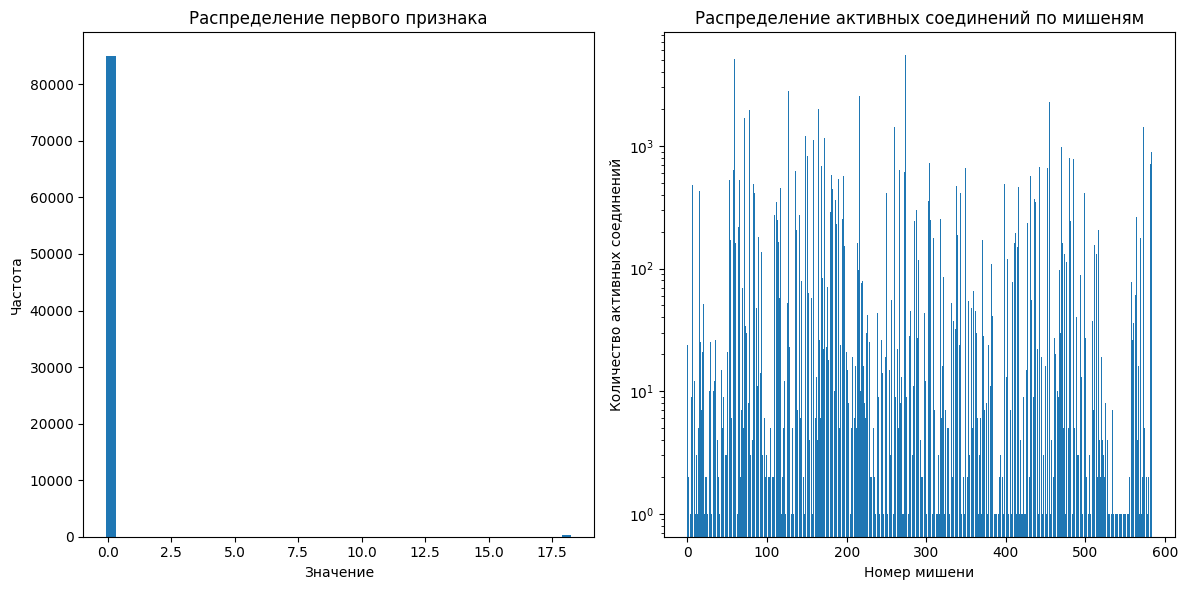

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

print("\nПроверка и визуализация результатов...")

# Проверка размеров
print(f"Размер матрицы признаков X: {X_scaled.shape}")
print(f"Размер матрицы целевых переменных y: {y.shape}")

# Распределения признаков
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.hist(X_scaled[:, 0], bins=50)
plt.title("Распределение первого признака")
plt.xlabel("Значение")
plt.ylabel("Частота")

# Распределения вероятностей активности
plt.subplot(1, 2, 2)
active_counts = y.sum(axis=0)
plt.bar(range(len(active_counts)), active_counts)
plt.title("Распределение активных соединений по мишеням")
plt.xlabel("Номер мишени")
plt.ylabel("Количество активных соединений")
plt.yscale("log")

plt.tight_layout()


Средняя доля активных соединений по мишеням:
Минимум: 0.0000
Максимум: 0.0644
Среднее: 0.0021

Корреляция между мишенями (первые 10):
Корреляция сохранена в 'target_correlation.png'

Подготовка данных завершена!
Данные готовы для обучения модели в model.ipynb


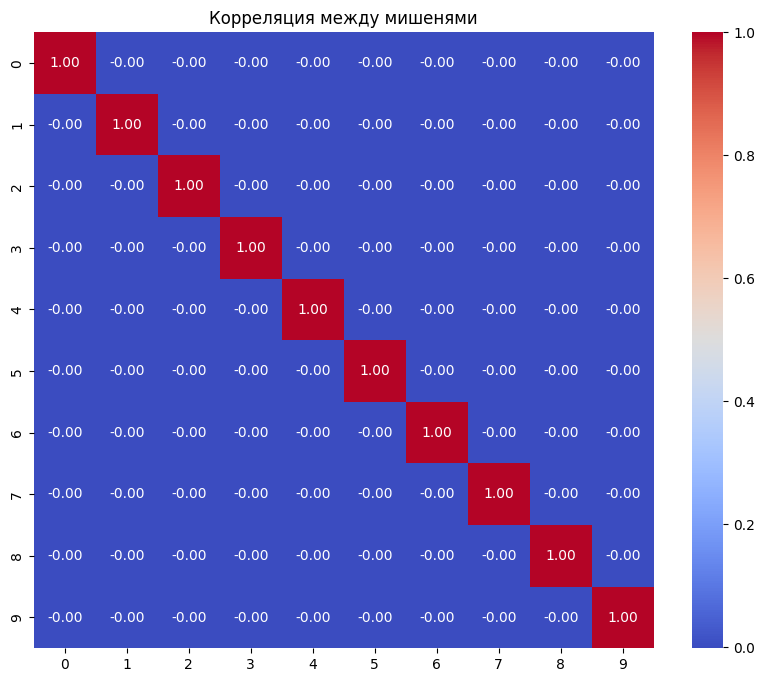

In [ ]:
# Проверка баланса классов
positive_ratio = np.mean(y, axis=0)
print("\nСредняя доля активных соединений по мишеням:")
print(f"Минимум: {np.min(positive_ratio):.4f}")
print(f"Максимум: {np.max(positive_ratio):.4f}")
print(f"Среднее: {np.mean(positive_ratio):.4f}")

# Проверка корреляции между мишенями
if y.shape[1] > 1:
    print("\nКорреляция между мишенями (первые 10):")
    corr = np.corrcoef(y.T)[:10, :10]
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
    plt.title("Корреляция между мишенями")
else:
    print("\nНедостаточно мишеней для вычисления корреляции")

print("\n\033[92mПодготовка данных завершена!\033[0m")
print("Данные готовы для обучения модели в model.ipynb")